# Biomedical Image Processing Large Assignment

Made by: Werner Huiskes, Lise Kleinbekman

In this assignment, you will process a medical image using various image processing techniques.
Please make sure to include your student ID in the respective field in the first code cell.

## Image Source
The image used in this assignment is from MedPix. You can find more information about the clinical background of the image [here](https://medpix.nlm.nih.gov/case?id=4e67ac56-efb4-49e6-b655-2c0945901cc9).

## Tasks
You will complete the following tasks:
1) Load the image
2) Add noise to the image based on your student ID
3) Denoise the image using a Gaussian filter
4) Apply thresholding
5) Perform morphological operations to refine the segmentation
6) Load the reference segmentation, compare it with yours using
appropriate metrics * , and briefly explain the differences and
quality in a comment or text within the notebook.
8) Apply edge detection to identify where the segmentation overlaps
with the intensity image, avoiding the soft tissue.
9) Extract features from the image: Label and visualize regions
10) Extract features from the image: Extract and print region feature

Let's get started!

## Task 1: Load the Image and Necessary Libraries

In this first step, the X-ray image of the hand is loaded from the local project folder. The original method of reading in the image via the web link can be unstable from time to time, so doing it this way ensures that the rest of the code runs so long as the file is present. The image is also read in as a grayscale image to ensure that later processing steps (like thresholding and noise addition) work properly.

Image loaded from: C:\Users\Lise\Desktop\LST\LST year 3\IIb\BIP\image.png
Image shape: (613, 472)
Image data type: float64
Minimum intensity: 0.0
Maximum intensity: 0.9255


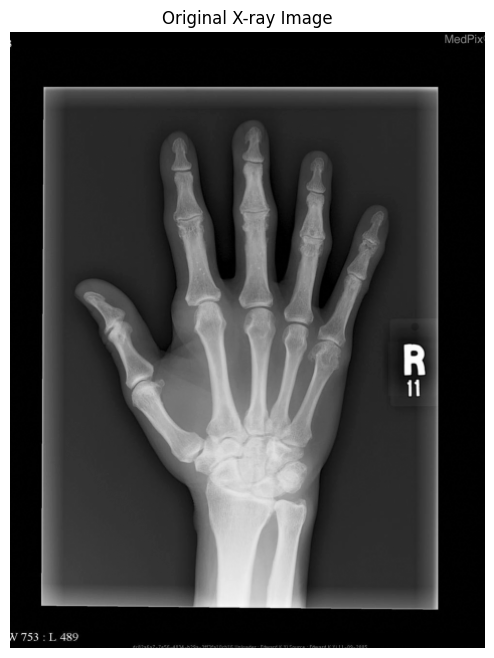

In [21]:
# Import necessary libraries
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, feature, measure, util
from scipy import ndimage
from skimage.color import label2rgb
import matplotlib
import cv2
import pandas as pd

# Tweak the figure size so it isn't so small by default
matplotlib.rcParams['figure.figsize'] = (10, 5)

# Enter your student ID here
student_id = 'S6560075'

# Define the local image path, this can be changed depending on where the image is located at
image_path = Path(r"C:\Users\Lise\Desktop\LST\LST year 3\IIb\BIP\image.png")

# Load the image as a grayscale image
image = io.imread(image_path, as_gray=True)

# Print basic image information to check that the image has loaded correctly
print("Image loaded from:", image_path)
print("Image shape:", image.shape)
print("Image data type:", image.dtype)
print("Minimum intensity:", round(np.min(image), 4))
print("Maximum intensity:", round(np.max(image), 4))

# Display the original image
plt.figure(figsize=(8, 8))
plt.title('Original X-ray Image')
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

## Task 2: Add noise to the image based on your student ID

In this task, you will add noise to the image based on your student ID.
Use the `util.random_noise` function from `skimage` to add Gaussian noise to the image.

### Steps:
1. Convert your student ID to an integer seed value.
2. Use the seed value to generate random noise.
3. Add the noise to the image.

For this task, we convert the student ID into an integer seed by summing the character codes of all characters in the ID. This seed is then used when we add the Gaussian noise, so that the noisy image remains reproducible for the same student ID. The original image is kept unchanged in the variable `image`, while the noisy version is stored separately as `noisy_image`. This latter image variable is then used for the later tasks.

Student ID: S6560075
Seed value: 448
Noise mean: 0
Noise variance: 0.01
Noisy image minimum intensity: 0.0
Noisy image maximum intensity: 1.0


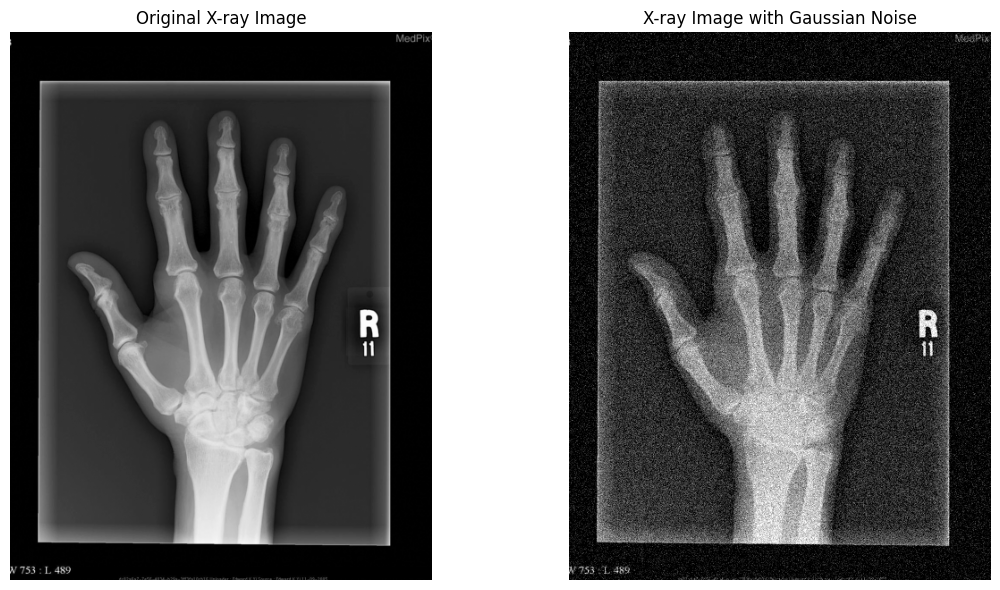

In [22]:
# Convert student ID to integer seed value
IDseed = sum([ord(char) for char in student_id])
np.random.seed(IDseed)

# Add Gaussian noise to the image
# The random seed is based on the previous student ID, so the results remain reproducible
noise_mean = 0
noise_variance = 0.01 # this value can be increased to generate stronger Gaussian noise

# util.random_noise function is used here from skimage to apply the Gaussian noise
noisy_image = util.random_noise(image, mode='gaussian', mean=noise_mean, var=noise_variance, rng=IDseed)

# Print basic information about the noisy image
print("Student ID:", student_id)
print("Seed value:", IDseed)
print("Noise mean:", noise_mean)
print("Noise variance:", noise_variance)
print("Noisy image minimum intensity:", round(np.min(noisy_image), 4)) # round used to prevent large amounts of floating numbers
print("Noisy image maximum intensity:", round(np.max(noisy_image), 4))

# Display the original and noisy image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original X-ray Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('X-ray Image with Gaussian Noise')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 3: Denoise the image using a Gaussian filter

Write your own code to denoise the image with the noise added based on your student ID and then assess how well your denoising worked.

For the next task we need to take the noisy image from task 2 and denoise it using a Gaussian filter. We can use a Gaussian kernel for this and apply a convolution, similar to the notebook assignments on convolutions we did before in the course. 

The result can be checked visually and quantitatively by comparing the noisy and denoised images to the original image using PSNR and SSIM metrics, similar also to previous assignments. A higher PSNR and a higher SSIM indicate better recovery of the original image.

Gaussian filter settings:
Kernel size: 5
Sigma: 1.0
Noisy image PSNR: 20.97
Denoised image PSNR: 28.0306
Noisy image SSIM: 0.1976
Denoised image SSIM: 0.5614


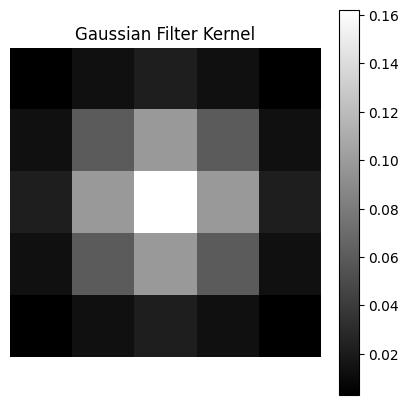

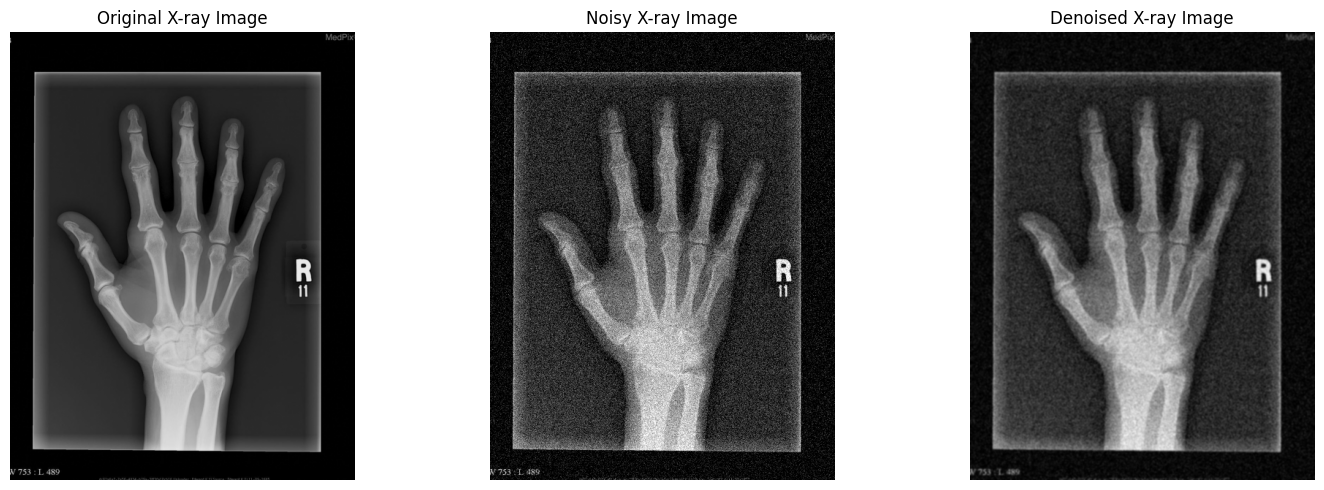

In [23]:
# Apply denoising to the image
from scipy.signal import convolve2d # necessary extra packages for SSIM and PSNR, and also convolve2d for convolutions
from skimage import metrics

# Create a Gaussian kernel, based on the same function we used in the convolution exercise notebook
def gaussian_kernel(size, sigma=1):
    """Creates a normalized 2D Gaussian kernel."""
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    gaussian = np.exp(-((x**2 + y**2) / (2.0 * sigma**2))) * normal
    
    # Normalize the kernel so that the total intensity is preserved
    gaussian = gaussian / np.sum(gaussian)
    
    return gaussian

# Choose Gaussian filter settings, higher values create stronger convolution effects
kernel_size = 5
sigma = 1.0

# Create the Gaussian kernel itself
gaussian_filter_kernel = gaussian_kernel(kernel_size, sigma=sigma)

# Apply the Gaussian filter to the noisy image
denoised_image = convolve2d(noisy_image, gaussian_filter_kernel, mode='same', boundary='symm')

# Keep the denoised image in a clean_image variable for the next tasks. This is to prevent accidental overwrites.
# Store the denoised image as clean_image for the next tasks
clean_image = np.clip(denoised_image, 0, 1)

# Assess denoising quality using PSNR and SSIM
psnr_noisy = metrics.peak_signal_noise_ratio(image, noisy_image, data_range=1.0)
psnr_clean = metrics.peak_signal_noise_ratio(image, clean_image, data_range=1.0)

ssim_noisy = metrics.structural_similarity(image, noisy_image, data_range=1.0)
ssim_clean = metrics.structural_similarity(image, clean_image, data_range=1.0)

# Print the chosen filter settings and quality measurements
print("Gaussian filter settings:")
print("Kernel size:", kernel_size)
print("Sigma:", sigma)

print("Noisy image PSNR:", round(psnr_noisy, 4))
print("Denoised image PSNR:", round(psnr_clean, 4))

print("Noisy image SSIM:", round(ssim_noisy, 4))
print("Denoised image SSIM:", round(ssim_clean, 4))

# Display the Gaussian kernel
plt.figure(figsize=(5, 5))
plt.title('Gaussian Filter Kernel')
plt.imshow(gaussian_filter_kernel, cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

# Display the original, noisy and denoised images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Original X-ray Image')
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Noisy X-ray Image')
plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Denoised X-ray Image')
plt.imshow(clean_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()

Focus on a ROI

For the ROI crop of the hand itself, several crop settings were tested in a trial and error fashion. This is due to the hand not being perfectly centered in the image. By cropping each region (top, bottom, left, right) individually based on the image dimensions we get a much cleaner view of the hand. This also allows for another assessment of the denoising effect, since irrelevant structures are no longer visible in this cropped ROI. 

Final ROI crop:
Top: 79
Bottom: 570
Left: 56
Right: 387
ROI noisy image PSNR: 20.3871
ROI denoised image PSNR: 30.4725
ROI noisy image SSIM: 0.2128
ROI denoised image SSIM: 0.6966


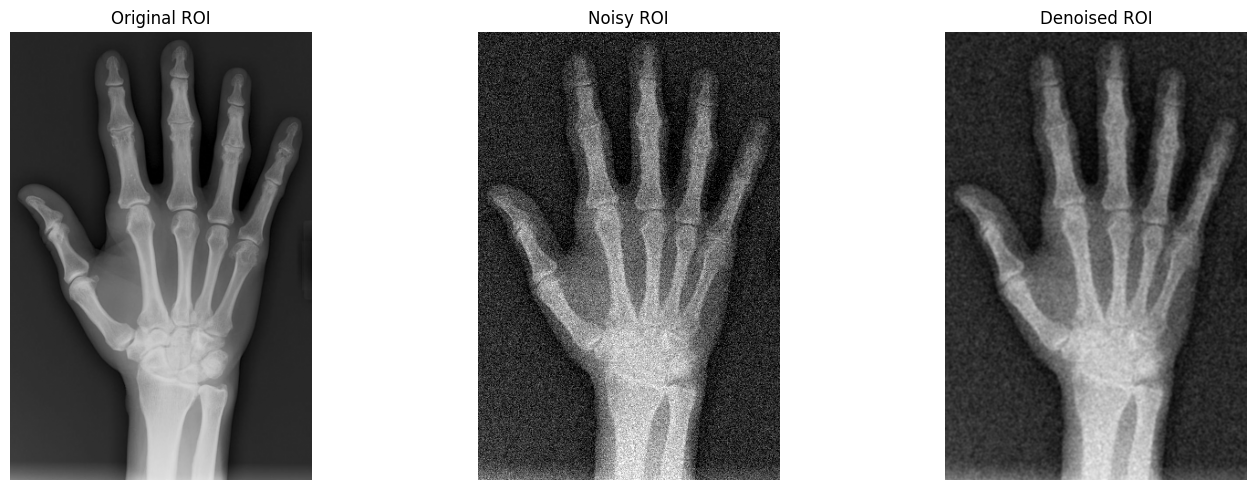

In [24]:
# Focus on a ROI

# Get the image dimensions
image_height = image.shape[0]
image_width = image.shape[1]

# Define the final ROI crop indices
# These values were selected by trial and error to keep the hand intact
crop_top = int(image_height * 0.13)
crop_bottom = int(image_height * 0.93)
crop_left = int(image_width * 0.12)
crop_right = int(image_width * 0.82)

# Crop the same ROI from the original, noisy and denoised images
roi_image = image[crop_top:crop_bottom, crop_left:crop_right]
roi_noisy_image = noisy_image[crop_top:crop_bottom, crop_left:crop_right]
roi_clean_image = clean_image[crop_top:crop_bottom, crop_left:crop_right]

# Assess denoising quality in the ROI using the same PSNR and SSIM metrics
roi_psnr_noisy = metrics.peak_signal_noise_ratio(roi_image, roi_noisy_image, data_range=1.0)
roi_psnr_clean = metrics.peak_signal_noise_ratio(roi_image, roi_clean_image, data_range=1.0)

roi_ssim_noisy = metrics.structural_similarity(roi_image, roi_noisy_image, data_range=1.0)
roi_ssim_clean = metrics.structural_similarity(roi_image, roi_clean_image, data_range=1.0)

# Print ROI crop settings and quality measurements
print("Final ROI crop:")
print("Top:", crop_top) # index numbers
print("Bottom:", crop_bottom)
print("Left:", crop_left)
print("Right:", crop_right)

print("ROI noisy image PSNR:", round(roi_psnr_noisy, 4))
print("ROI denoised image PSNR:", round(roi_psnr_clean, 4))

print("ROI noisy image SSIM:", round(roi_ssim_noisy, 4))
print("ROI denoised image SSIM:", round(roi_ssim_clean, 4))

# Display the ROI before and after denoising
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('Original ROI')
plt.imshow(roi_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Noisy ROI')
plt.imshow(roi_noisy_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Denoised ROI')
plt.imshow(roi_clean_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()

The Gaussian filter visibly reduces the added noise and is closer to the original image, shown also by higher PSNR and SSIM values. The ROI crop gives better PSNR and SSIM results than the full image because it focuses directly on the relevant X-ray anatomy.

## Task 4: Apply Thresholding

In this task, you will apply thresholding to the denoised image to create a binary image.
Write code to obtain two different images, one containing the bony structures in the image and one containing the soft-tissue structures.

For thresholding, we make use of the denoised ROI image from task 3. First, the histogram is inspected and Otsu's method is applied as an automatic thresholding method for comparison. Then manual thresholding is used with two thresholds, so that separate images can be made for soft tissue structures and bony structures.

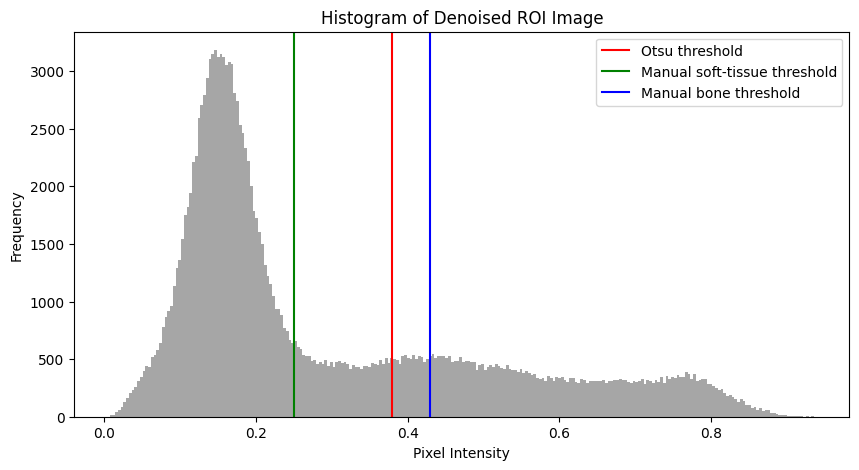

Otsu threshold: 0.379
Manual soft tissue threshold: 0.25
Manual bone threshold: 0.43


In [25]:
# Write your thresholding code here

# Use the denoised ROI image for thresholding
threshold_image = roi_clean_image

# Calculate Otsu's automatic threshold
otsu_threshold = filters.threshold_otsu(threshold_image)

# Choose manual thresholds after inspecting the histogram
# These values can be adjusted slightly if the visual result is not optimal
manual_soft_tissue_threshold = 0.25
manual_bone_threshold = 0.43 # right around a small peak of brighter values, most likely bone structure

# Create histogram to find interesting regions
plt.figure(figsize=(10, 5))
plt.hist(threshold_image.ravel(), bins=256, color='gray', alpha=0.7)
plt.axvline(otsu_threshold, label="Otsu threshold", color='red')
plt.axvline(manual_soft_tissue_threshold, label="Manual soft-tissue threshold", color='green')
plt.axvline(manual_bone_threshold, label="Manual bone threshold", color='blue')
plt.title('Histogram of Denoised ROI Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Print threshold values
print("Otsu threshold:", round(otsu_threshold, 4))
print("Manual soft tissue threshold:", manual_soft_tissue_threshold)
print("Manual bone threshold:", manual_bone_threshold)

The histogram shows a large peak at lower intensities, followed by a longer tail containing the brighter tissue and bone structures. Otsu's threshold gives a useful reference, but clearly the manual thresholds are needed to separate the soft tissues and bone specifically. A bit of trial and error gives us values of 0.25 for  the soft tissues, and 0.43 for the bones.

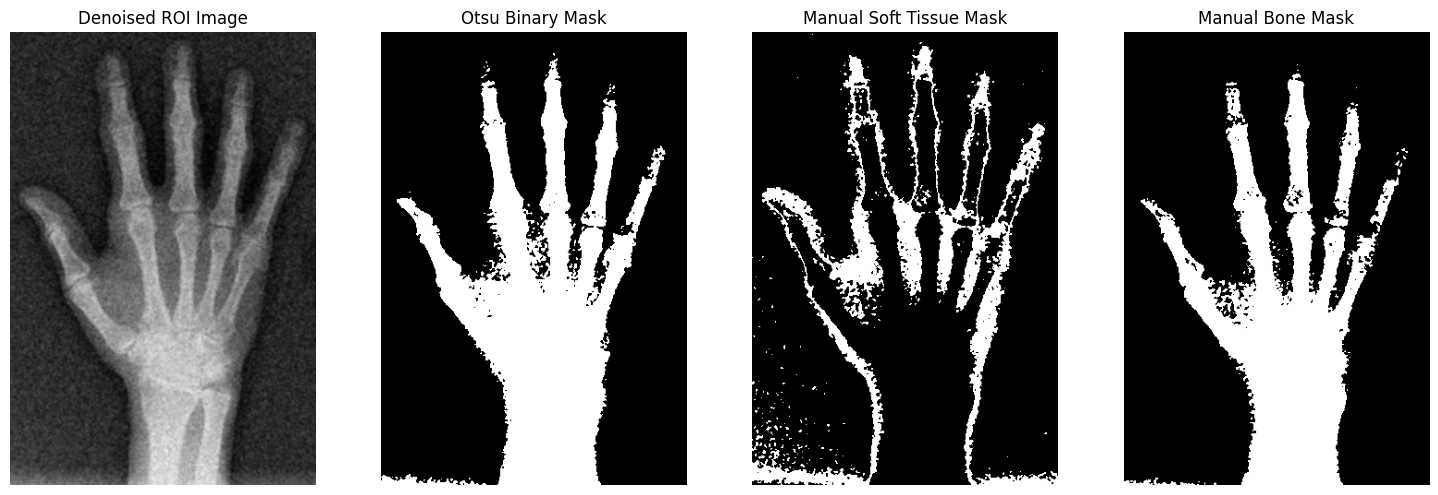

In [26]:
# Create binary threshold results

# Use selected thresholds based on the histogram inspection
manual_soft_tissue_threshold = 0.25
manual_bone_threshold = 0.43

# Otsu creates one automatic binary separation
otsu_mask = threshold_image > otsu_threshold

# Soft tissue is represented by the intermediate intensity values
soft_tissue_mask = (threshold_image > manual_soft_tissue_threshold) & (threshold_image <= manual_bone_threshold)

# Bone is represented by the highest intensity values
bone_mask = threshold_image > manual_bone_threshold

# Store the final binary images with consistent naming schemes
soft_tissue = soft_tissue_mask
bones = bone_mask

# Display the binary threshold results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title('Denoised ROI Image')
plt.imshow(threshold_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Otsu Binary Mask')
plt.imshow(otsu_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Manual Soft Tissue Mask')
plt.imshow(soft_tissue, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Manual Bone Mask')
plt.imshow(bones, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

The thresholded binary masks show the detection of the hand structures, but these results still contain noisy regions and rough edges that will need further refinement. Otsu's method gives a mask close to the manual bone mask results, with the latter being a bit more restrictive to what is considered bone. These masks are good enough for subsequent morphological operations, but especially the soft tissue mask needs extra refinement.

## Task 5: Perform morphological operations to refine the segmentation
In this task, you will apply morphological operations to the thresholded images to enhance the segmentation results. The goal is to:

* Clean up noise and small artifacts in both the bony structures and soft tissue regions.
* Separate connected components, especially in the skeleton, so that individual bones (e.g., phalanges, metacarpals) can be distinguished rather than appearing as one large connected object.
* Preserve important anatomical features while removing irrelevant details. You may need to experiment with different structuring elements and operation sequences to achieve optimal separation and clarity.



Refinement of the binary masks from task 4 (soft_tissue and bones) is done by making use of morphological operations. For these, we take direct inspiration from the notebook assignments on this topic. Operations like opening remove small noisy foreground regions, while closing smooths small gaps. We can also directly remove small objects and holes to clean up the masks while preserving the hand structure itself.

C:\Users\Lise\AppData\Local\Temp\ipykernel_31948\2641353192.py:13: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  bones_opened = morphology.binary_opening(morpho_bones, medium_disk)
C:\Users\Lise\AppData\Local\Temp\ipykernel_31948\2641353192.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bones_cleaned = morphology.remove_small_objects(bones_opened, min_size=150)
C:\Users\Lise\AppData\Local\Temp\ipykernel_31948\2641353192.py:19: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morph

Bone foreground pixels before cleanup: 41114
Bone foreground pixels after cleanup: 39252
Bone connected regions after cleanup: 4
Soft-tissue foreground pixels before cleanup: 24142
Soft-tissue foreground pixels after cleanup: 24327
Soft-tissue connected regions after cleanup: 5


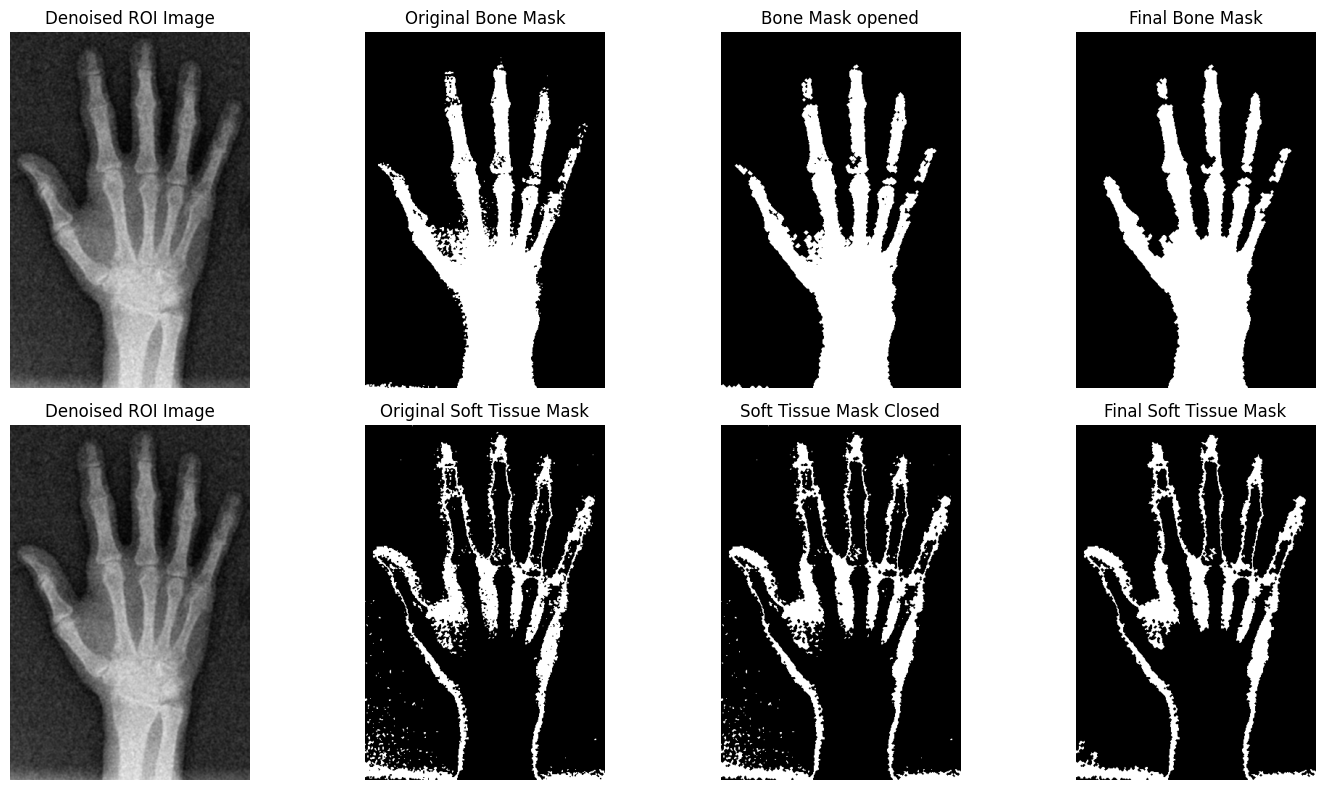

In [27]:
# Morphological operations to refine the segmentation

# Start from the binary masks created in task 4 in new seperate variables
morpho_bones = bones
morpho_soft = soft_tissue

# Define structuring elements
small_disk = morphology.disk(1)
medium_disk = morphology.disk(2)

# Clean up the bone mask
# Opening removes small foreground noise
bones_opened = morphology.binary_opening(morpho_bones, medium_disk)

# Remove small isolated objects
bones_cleaned = morphology.remove_small_objects(bones_opened, min_size=150)

# Closing smooths small gaps in the remaining bone structures
bones_closed = morphology.binary_closing(bones_cleaned, small_disk)

# Fill small holes inside segmented bone regions
morpho_bones = morphology.remove_small_holes(bones_closed, area_threshold=80)

# Clean up the soft-tissue mask more gently
# Soft tissue is thin and fragmented, so more aggressive cleanup removes useful structures
soft_closed = morphology.binary_closing(morpho_soft, small_disk)

# Use a low min_size so small soft-tissue structures are not removed too strongly
morpho_soft = morphology.remove_small_objects(soft_closed, min_size=25)

# Count connected regions after morphological cleanup
bone_label_image, num_bone_regions = measure.label(morpho_bones, return_num=True, connectivity=2)
soft_label_image, num_soft_regions = measure.label(morpho_soft, return_num=True, connectivity=2)

# Print simple cleanup information
print("Bone foreground pixels before cleanup:", np.sum(bones))
print("Bone foreground pixels after cleanup:", np.sum(morpho_bones))
print("Bone connected regions after cleanup:", num_bone_regions)

print("Soft-tissue foreground pixels before cleanup:", np.sum(soft_tissue))
print("Soft-tissue foreground pixels after cleanup:", np.sum(morpho_soft))
print("Soft-tissue connected regions after cleanup:", num_soft_regions)

# Display the morphological results
plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.title('Denoised ROI Image')
plt.imshow(threshold_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(2, 4, 2)
plt.title('Original Bone Mask')
plt.imshow(bones, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.title('Bone Mask opened')
plt.imshow(bones_opened, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.title('Final Bone Mask')
plt.imshow(morpho_bones, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.title('Denoised ROI Image')
plt.imshow(threshold_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(2, 4, 6)
plt.title('Original Soft Tissue Mask')
plt.imshow(soft_tissue, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.title('Soft Tissue Mask Closed')
plt.imshow(soft_closed, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.title('Final Soft Tissue Mask')
plt.imshow(morpho_soft, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

The bone mask improves clearly after performing opening, removing small objects, closing and hole filling operations. Some residual soft tissue is still visible, but the bone structure is more identifiable than the original mask. For the bone mask, the operations were also reversed to see the difference. When first using the closing and then the opening operator, some of the fingertips and the thumb became better visible. However, this also led to an increase in connected regions (to 5), the detection of some of the background around the edges and less alignment around the wrist area. 

 For the soft tissue it is much harder to strike a balance between noise removal and tissue conservation. For this reason only light closing and small object removal operations are used. Stronger operations remove too much of the already fragmented soft tissue structure. The opening operation was also tried, but showed many more connected regions (32) and a lot of small islands. Therefore, the closing operation was used. 

## Task 6: Load the reference segmentation, compare it with yours using appropriate metrics, and briefly explain the differences and quality in a comment or text within the notebook.

*Note* : The reference segmentation is a baseline, not ground truth; your
segmentation may match or outperform it, and this should be considered
in your interpretation

The reference segmentation which we need to compare to was provided on brightspace, and is also loaded in locally here and then converted to a binary mask. We can then compare this binary mask to the refined binary mask that we have created ourselves after the morphological operations above. Because our segmentation was created on a cropped ROI in Task 3, we also apply this same ROI crop to the reference image. Our bone mask is then compared with the reference mask using a dice score, IoU score (Jaccard Index), accuracy and hausdorff distance.

Reference image shape: (613, 472)
Reference ROI shape: (491, 331)
Our segmentation shape: (491, 331)
Dice score: 0.8118
Accuracy: 0.8991
IoU score: 0.6832
Sensitivity: 0.7389
Specificity: 0.966
PPV: 0.9005
NPV: 0.8987
Hausdorff distance: 64.62 pixels


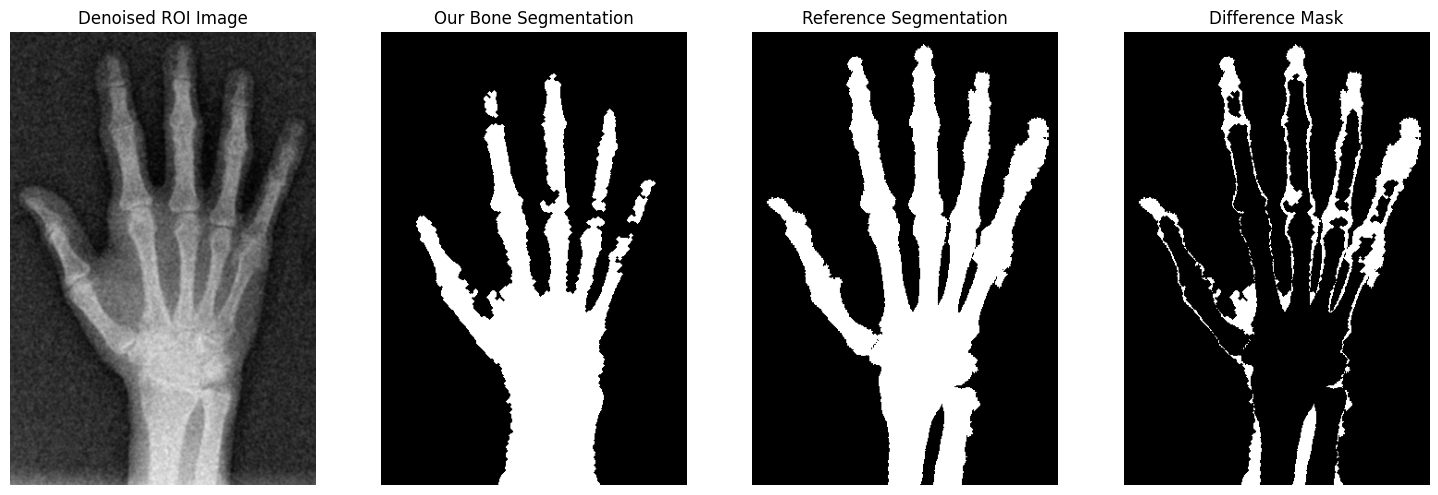

In [28]:
# Code Task 6

# Define the local reference segmentation path
reference_path = Path(r"C:\Users\Lise\Desktop\LST\LST year 3\IIb\BIP\hand_binary.png")

# Load the reference segmentation as grayscale
reference_image = io.imread(reference_path, as_gray=True)

# Convert the reference image to a binary mask
reference_binary = reference_image > 0.5

# Use the final refined bone mask from task 5 as our segmentation
our_segmentation = morpho_bones

# Align the reference segmentation to the same ROI as our segmentation
# If the reference image has the same size as the original image, crop it with the same ROI coordinates
if reference_binary.shape == image.shape:
    reference_roi = reference_binary[crop_top:crop_bottom, crop_left:crop_right]

# If the reference already has the same size as our ROI, use it directly
elif reference_binary.shape == our_segmentation.shape:
    reference_roi = reference_binary

# Define a function to calculate segmentation metrics
def calculate_segmentation_metrics(reference_mask, predicted_mask):
    """Calculates Dice score, accuracy, IoU and Hausdorff distance."""
    
    # Ensure both masks are binary
    reference_mask = reference_mask > 0
    predicted_mask = predicted_mask > 0
    
    # Calculate true/false positives and negatives using logical operations
    true_positive = np.sum(reference_mask & predicted_mask)
    true_negative = np.sum(~reference_mask & ~predicted_mask)
    false_positive = np.sum(~reference_mask & predicted_mask)
    false_negative = np.sum(reference_mask & ~predicted_mask)
    
    # Calculate overlap-based metrics
    dice_score = (2 * true_positive) / (2 * true_positive + false_positive + false_negative) if (2 * true_positive + false_positive + false_negative) > 0 else 0
    accuracy = (true_positive + true_negative) / reference_mask.size if reference_mask.size > 0 else 0
    iou_score = true_positive / (true_positive + false_positive + false_negative) if (true_positive + false_positive + false_negative) > 0 else 0
    sensitivity = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
    specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
    PPV = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
    NPV = true_negative / (true_negative + false_negative) if (true_negative + false_negative) > 0 else 0
    
    # Calculate Hausdorff distance
    # This measures the largest distance between the two segmented shapes
    if np.any(reference_mask) and np.any(predicted_mask):
        hausdorff_distance = metrics.hausdorff_distance(reference_mask, predicted_mask)
    else:
        hausdorff_distance = np.nan
    
    return dice_score, accuracy, iou_score, sensitivity, specificity, PPV, NPV, hausdorff_distance

# Calculate metrics
dice_score, accuracy_score, iou_score, sensitivity_score, specificity_score, PPV_score, NPV_score, hausdorff_distance = calculate_segmentation_metrics(reference_roi, our_segmentation)

# Print the results
print("Reference image shape:", reference_binary.shape)
print("Reference ROI shape:", reference_roi.shape)
print("Our segmentation shape:", our_segmentation.shape)

print("Dice score:", round(dice_score, 4))
print("Accuracy:", round(accuracy_score, 4))
print("IoU score:", round(iou_score, 4))
print("Sensitivity:", round(sensitivity_score, 4))
print("Specificity:", round(specificity_score, 4))
print("PPV:", round(PPV_score, 4))
print("NPV:", round(NPV_score, 4))
print("Hausdorff distance:", round(hausdorff_distance, 2), "pixels")

# Create a simple difference mask
# White pixels show where our segmentation and the reference disagree
difference_mask = reference_roi != our_segmentation

# Display the comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title('Denoised ROI Image')
plt.imshow(threshold_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title('Our Bone Segmentation')
plt.imshow(our_segmentation, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title('Reference Segmentation')
plt.imshow(reference_roi, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title('Difference Mask')
plt.imshow(difference_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

This comparison gives a dice score of 0.8118, an accuracy of 0.8991, IoU of 0.6832, sensitivity of 0.7389, specificity of 0.9660, PPV of 0.9005, NPV of 0.8987 and a Hausdorff distance of 64.62 pixels. These values show a reasonably strong overlap, although the difference mask shows clear boundary and thickness differences between the two segmentations. One obvious difference between the two segmentations is the lack of differentiation between the ulna and radius bone in our bone segmentation. This is instead clearly defined in the reference segmentation. Our segmentation therefore appears broader than the reference segmentation in this region, but is more selective on bony structure more distally. Since the reference is a baseline rather than ground truth, this is a balance between overlap score and anatomical selectivity, but it seems that our bone segmentation is rougher around the boundary edges.

This is also the reason why the Jaccard Index is quite a bit lower than the dice score. The dice score gives more weighting towards overlapping regions, while the Jaccard Index corrects for this by taking differences more into account. The clear differences around the boundary edges and at the proximal radius and ulna bone cause this jump to occur, and also increases the Hausdorff distance as well. 

The accuracy metric might be misleading in this case, as it the majority of the image is background. Therefore, the classes are not entirely balanced and the accuracy does not take an imbalance in classes into account. 

The sensitivity gives information about how much of the true object (reference segmentation) was detected. As we can see in the differences image, there are quite some regions that are not overlapping. This is also reflected in the lower sensitivity. On the other side, the specificity metric is quite high. This might be misleading in this case as it focusses on the false positives and does not consider false negatives. The high specificity indicates that the false positives are quite low. As mentioned, the false negatives are not considered and therefore the high specificity is likely quite misleading. 

## Task 7: Apply edge detection to identify where the segmentation overlaps with the intensity image, avoiding the soft tissue

In this task, you will apply edge detection to the result of the morphological operations to get the outline of the bones and the soft tissue.

C:\Users\Lise\AppData\Local\Temp\ipykernel_31948\3636741451.py:34: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  true_boundary = morpho_bones ^ morphology.binary_erosion(morpho_bones)


Edge-detection method scores (same metrics as Task 6):
  method                    Dice     IoU   Sens.  Hausdorff
  Sobel (ksize=3)         0.5037  0.3366  1.0000       1.41
  Sobel (ksize=7)         0.2180  0.1223  1.0000       4.24
  Canny (5, 50)           0.5646  0.3934  0.6275       1.41
  Canny (50, 150)         0.5646  0.3934  0.6275       1.41
  Canny (150, 250)        0.5646  0.3934  0.6275       1.41
  Laplacian of Gaussian   0.2320  0.1313  0.9956       3.61

-> Selected edge detector: Canny (5, 50) (Dice = 0.5646, Hausdorff = 1.41)


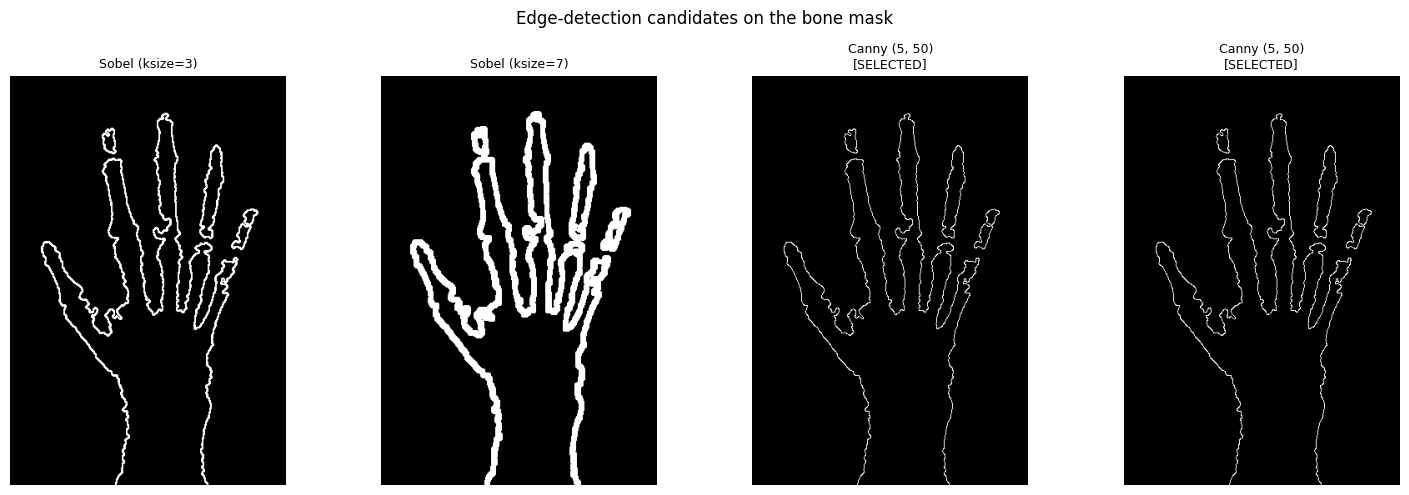

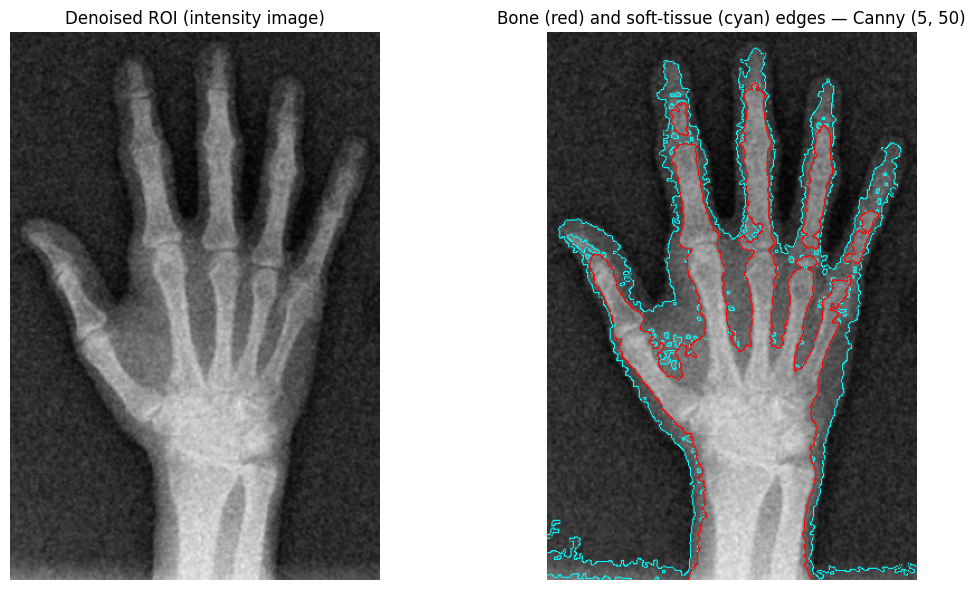

In [29]:
# Code task 7 

# OpenCV edge detection expects an 8-bit image, so convert the binary masks
bone_mask_uint8 = (morpho_bones * 255).astype(np.uint8)
soft_mask_uint8 = (morpho_soft * 255).astype(np.uint8)

# A single function that produces an edge map for a given method configuration. 
def detect_edges(mask_uint8, method):
    """Return a boolean edge map for the chosen edge-detection method."""
    if method['name'] == 'sobel':
        sx = cv2.Sobel(mask_uint8, cv2.CV_64F, 1, 0, ksize=method['ksize'])
        sy = cv2.Sobel(mask_uint8, cv2.CV_64F, 0, 1, ksize=method['ksize'])
        grad = cv2.addWeighted(cv2.convertScaleAbs(sx), 0.5,
                               cv2.convertScaleAbs(sy), 0.5, 0)
        return grad > 0
    elif method['name'] == 'canny':
        return cv2.Canny(mask_uint8, method['low'], method['high']) > 0
    elif method['name'] == 'log':                       # Laplacian of Gaussian
        blurred = cv2.GaussianBlur(mask_uint8, (5, 5), 0)
        lap = cv2.Laplacian(blurred, cv2.CV_64F)
        return cv2.convertScaleAbs(lap) > 0

# Candidate methods/settings the program is allowed to choose from 
candidates = [
    {'name': 'sobel', 'ksize': 3,            'label': 'Sobel (ksize=3)'},
    {'name': 'sobel', 'ksize': 7,            'label': 'Sobel (ksize=7)'},
    {'name': 'canny', 'low': 5,  'high': 50, 'label': 'Canny (5, 50)'},
    {'name': 'canny', 'low': 50, 'high': 150,'label': 'Canny (50, 150)'},
    {'name': 'canny', 'low': 150,'high': 250,'label': 'Canny (150, 250)'},
    {'name': 'log',                          'label': 'Laplacian of Gaussian'},
]

# Reference outline using the bone mask's boundary as the "true" edge. Each candidate's edges are compared to this, using the same metric function defined in Task 6.
true_boundary = morpho_bones ^ morphology.binary_erosion(morpho_bones)

# Use metrics from task 6 to determine which method gives the best results. 
print("Edge-detection method scores (same metrics as Task 6):")
print(f"  {'method':<22} {'Dice':>7} {'IoU':>7} {'Sens.':>7} {'Hausdorff':>10}")
results = []
for m in candidates:
    edges = detect_edges(bone_mask_uint8, m)
    dice, acc, iou, sens, spec, ppv, npv, hd = \
        calculate_segmentation_metrics(true_boundary, edges)
    results.append({'dice': dice, 'iou': iou, 'hd': hd})
    hd_str = f"{hd:10.2f}" if np.isfinite(hd) else f"{'nan':>10}"
    print(f"  {m['label']:<22} {dice:7.4f} {iou:7.4f} {sens:7.4f} {hd_str}")

# Pick the best method based on the highest dice score and the lowest Hausdorff distance. 
best_idx = int(np.argmax([(r['dice'], -r['hd']) for r in results], axis=0)[0]) \
    if False else max(range(len(results)),
                      key=lambda i: (results[i]['dice'], -results[i]['hd']))
best_method = candidates[best_idx]
print(f"\n-> Selected edge detector: {best_method['label']} "
      f"(Dice = {results[best_idx]['dice']:.4f}, "
      f"Hausdorff = {results[best_idx]['hd']:.2f})")

# Apply the best method to both the bone and soft-tissue masks
bone_edges = detect_edges(bone_mask_uint8, best_method)
soft_edges = detect_edges(soft_mask_uint8, best_method)

# Show the top 3 candidates so the choice is visible in the report 
plt.figure(figsize=(15, 5))
for i, m in enumerate(candidates[:3] + [best_method]):
    plt.subplot(1, 4, i + 1)
    plt.imshow(detect_edges(bone_mask_uint8, m), cmap='gray')
    title = m['label'] + ("\n[SELECTED]" if m is best_method else "")
    plt.title(title, fontsize=9)
    plt.axis('off')
plt.suptitle('Edge-detection candidates on the bone mask')
plt.tight_layout()
plt.show()

# Overlay the bone (red) and soft-tissue (cyan) outlines 
overlay = np.dstack([threshold_image, threshold_image, threshold_image])
overlay[soft_edges] = [0, 1, 1]   
overlay[bone_edges] = [1, 0, 0]   

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(threshold_image, cmap='gray', vmin=0, vmax=1)
plt.title('Denoised ROI (intensity image)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay)
plt.title(f'Bone (red) and soft-tissue (cyan) edges — {best_method["label"]}')
plt.axis('off')

plt.tight_layout()
plt.show()

# Pass the refined masks on to the feature-extraction task using consistent names
mask_bones = morpho_bones
mask_soft = morpho_soft


The for-loop with the metrics is not perfect, as there are multiple options that lead to the same/similar outcome. The only thing that varies is line thickness between some of the methods. This is something that the metrics don't take into account. Aside from that, the evaluation of the edge detection based on the metrics works pretty well as it is consistent with the mask. 

The bone detection nicely overlaps with the mask, but is also not a perfect overlap with the original image. This is because the mask is also not a perfect overlap with the original image as mentioned before. The bone edge detection does show a really good overlap with the refined bone mask. Any deviations from the original image are consistent with the differences between the refined bone mask and the original image. 

The overlap for the soft tissue is quite poor. Soft tissue is more difficult to detect, as it has lower contrast and the intensities of the soft tissue are not solely bound to the soft tissue itself. This is why the soft tissue mask contains a lot of small islands and also incorporates the top and bottom of the image and very small parts of dark bone regions. Its segmentation is therefore a lot poorer than for the bones and that is also why the canny edge detection for the soft tissue is not working as nicely as for the bone edge detection. 

## Tasks 8 and 9: Extract Features from Hand Skeleton and Soft Tissue
Goal of this task, you will identify and analyze different regions (bones and soft tissue) in the gray scale X-ray image. You will extract and report key features such as area and intensity statistics.

### Part 1/task 8 Label and Visualize Regions
* Label the bone and soft tissue regions using measure.label():
  - Use a mask of the bones and a mask for soft Tissues as input masks.
* Create overlay images to visualize the labeled regions
  - Use label2rgb() to overlay the labels on the mask images.
* Display the overlays side by side using matplotlib.pyplot
  - Show the bone overlay on the left and the soft tissue overlay on the right.

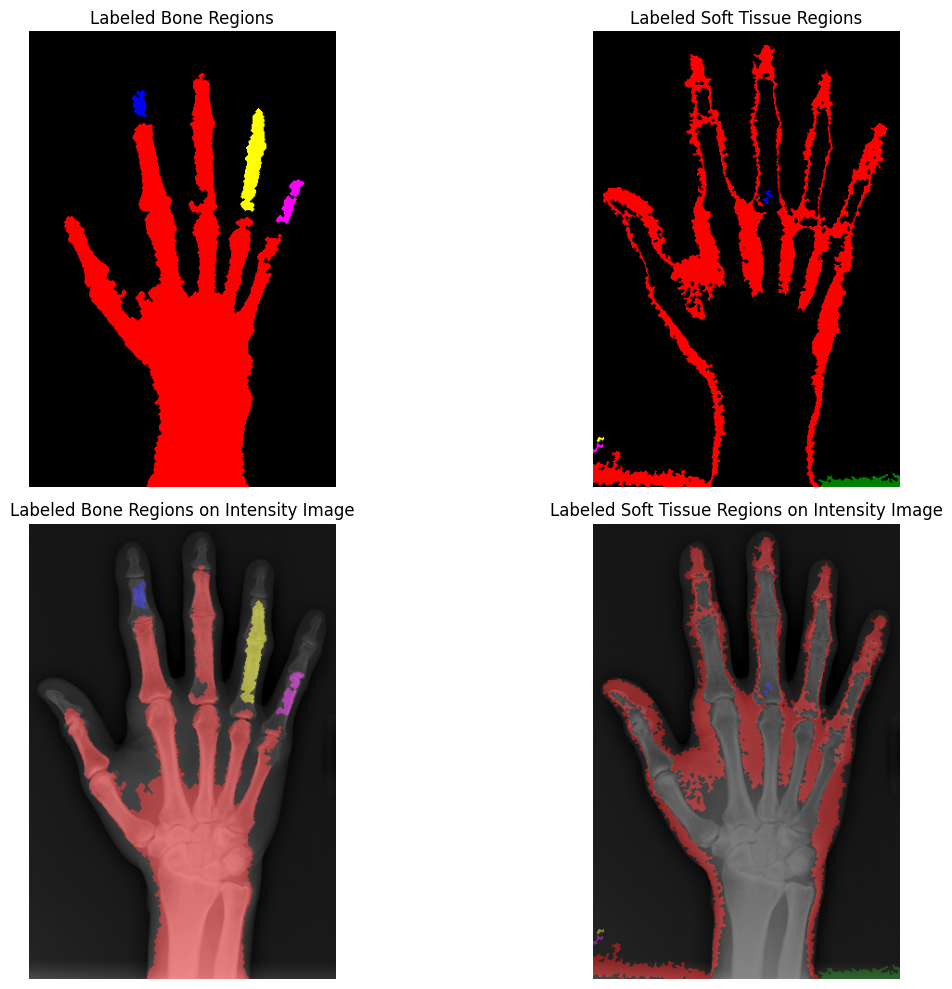

Number of bone regions: 4
Number of soft tissue regions: 5


In [30]:
#Code task 8

# Label the bone and soft tissue regions into separate connected components
labeled_bones = measure.label(mask_bones)
labeled_soft = measure.label(mask_soft)

# Create coloured overlays so that each region has its separate color. The background is set to black(0)
#The regions are overlaid on the original intensity image to show where the regions are in relation to the original image. 
bones_overlay_i = label2rgb(labeled_bones, image=roi_image, bg_label=0, alpha=0.4)
soft_overlay_i = label2rgb(labeled_soft, image=roi_image, bg_label=0, alpha=0.4)

#Overlay without the original image, so that the different regions are more clearly visible
bones_overlay = label2rgb(labeled_bones, bg_label=0)
soft_overlay = label2rgb(labeled_soft, bg_label=0)

# Display the overlays side by side (bones left, soft tissue right)
plt.figure(figsize=(14, 10))

# Top row: labels on a plain background
plt.subplot(2, 2, 1)
plt.imshow(bones_overlay)
plt.title('Labeled Bone Regions')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(soft_overlay)
plt.title('Labeled Soft Tissue Regions')
plt.axis('off')

# Bottom row: same labels overlaid on the intensity image
plt.subplot(2, 2, 3)
plt.imshow(bones_overlay_i)
plt.title('Labeled Bone Regions on Intensity Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(soft_overlay_i)
plt.title('Labeled Soft Tissue Regions on Intensity Image')
plt.axis('off')

plt.tight_layout()
plt.show()


# Number of bone regions and number of soft tissue regions.
print("Number of bone regions:", labeled_bones.max())
print("Number of soft tissue regions:", labeled_soft.max())


On the left, the bone segmentation is displayed for both without (top) and with (bottom) the intensity image as the background. The same is performed on the right for the soft tissues. 

The labeled overlays show that the refined bone mask contains 4 connected regions, while the refined soft tissue mask contains 5 connected regions. The bone regions are more anatomically sensible than the soft tissue regions. Still, we also see how the tips of the bones in the hand are not retained. Soft tissue regions also remain less reliable because of the soft tissue having lower contrast, and it overlapping more strongly with background and bone intensities.

### Part 2/task 9: Extract and Print Region Features
* Extract region properties using measure.regionprops():
  - Use your labeled bones and soft tissue images.
  - Use roi_image as the intensity_image.
* For each region, print the following features:
  - label
  - area
  - intensity_max
  - intensity_min
  - intensity_mean

In [31]:
#Code task 9

# Feature extraction for the bone regions. 
bone_regions = measure.regionprops(labeled_bones, intensity_image=roi_image)
print(f"Found {len(bone_regions)} bone region(s):")
for region in bone_regions:
    print(f"Bone {region.label} has area of: {region.area:.0f} px, "
          f"Max Intensity of: {region.intensity_max:.2f}, "
          f"Min intensity of: {region.intensity_min:.2f}, "
          f"Mean intensity of: {region.intensity_mean:.2f}")

# Feature extraction for the soft tissue regions. 
soft_regions = measure.regionprops(labeled_soft, intensity_image=roi_image)
print(f"\nFound {len(soft_regions)} soft tissue region(s):")
for region in soft_regions:
    print(f"SoftTissue {region.label} has area of: {region.area:.0f} px, "
          f"Max Intensity of: {region.intensity_max:.2f}, "
          f"Min intensity of: {region.intensity_min:.2f}, "
          f"Mean intensity of: {region.intensity_mean:.2f}")


#Make a nice table of the extracted features using pandas. 
rows = [] #collect the rows of the table in a list and then convert it to a dataframe. 
for region in measure.regionprops(labeled_bones, intensity_image=roi_image): #collect the features for the bone regions. 
    rows.append(['Bone', region.label, region.area,
                 region.intensity_max, region.intensity_min, region.intensity_mean])
for region in measure.regionprops(labeled_soft, intensity_image=roi_image): #collect the features for the soft tissue regions. 
    rows.append(['SoftTissue', region.label, region.area,
                 region.intensity_max, region.intensity_min, region.intensity_mean])

features_table = pd.DataFrame(rows, columns=['type', 'label', 'area',
                                             'intensity_max', 'intensity_min', 'intensity_mean']) #create dataframe with the collected rows and column names. 
features_table #display the table. 


Found 4 bone region(s):
Bone 1 has area of: 36871 px, Max Intensity of: 0.89, Min intensity of: 0.29, Mean intensity of: 0.63
Bone 2 has area of: 308 px, Max Intensity of: 0.53, Min intensity of: 0.38, Mean intensity of: 0.46
Bone 3 has area of: 1573 px, Max Intensity of: 0.60, Min intensity of: 0.38, Mean intensity of: 0.50
Bone 4 has area of: 500 px, Max Intensity of: 0.56, Min intensity of: 0.35, Mean intensity of: 0.47

Found 5 soft tissue region(s):
SoftTissue 1 has area of: 23401 px, Max Intensity of: 0.56, Min intensity of: 0.17, Mean intensity of: 0.34
SoftTissue 2 has area of: 63 px, Max Intensity of: 0.47, Min intensity of: 0.39, Mean intensity of: 0.44
SoftTissue 3 has area of: 26 px, Max Intensity of: 0.23, Min intensity of: 0.22, Mean intensity of: 0.22
SoftTissue 4 has area of: 41 px, Max Intensity of: 0.23, Min intensity of: 0.22, Mean intensity of: 0.23
SoftTissue 5 has area of: 796 px, Max Intensity of: 0.33, Min intensity of: 0.20, Mean intensity of: 0.28


,type,label,area,intensity_max,intensity_min,intensity_mean
0,Bone,1,36871.0,0.894118,0.294118,0.632768
1,Bone,2,308.0,0.533333,0.384314,0.461179
2,Bone,3,1573.0,0.600000,0.380392,0.501467
3,Bone,4,500.0,0.564706,0.352941,0.469953
4,SoftTissue,1,23401.0,0.556863,0.172549,0.341086
5,SoftTissue,2,63.0,0.474510,0.392157,0.435356
6,SoftTissue,3,26.0,0.227451,0.219608,0.223379
7,SoftTissue,4,41.0,0.231373,0.223529,0.227164
8,SoftTissue,5,796.0,0.333333,0.200000,0.280703


The feature table shows that the largest bone region has the highest mean intensity and by far the largest area, which reflects the connected bony structures in the segmentation. The smaller bone regions have lower mean intensities and are mostly separated or partially segmented bone structures. The soft tissue regions generally have lower mean intensities than the bone regions, which matches the thresholding logic, although the small soft tissue regions also show that this segmentation remains more fragmented and less anatomically reliable. A more refined segmentation would require better handling of the boundaries between the bony structures and the soft tissues, which would also make the labelled regions and feature table even more informative.